In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:0000:01


In [ ]:
from ultralytics import YOLO
import cv2
import time

# load pretrained model
model = YOLO("yolov8n.pt")

vehicle_classes = [2,3,5,7]
person_class = 0


def detect_objects(image_path):

    img = cv2.imread(image_path)

    results = model(img)

    vehicle_count = 0
    person_detected = False

    for r in results:

        for box in r.boxes:

            class_id = int(box.cls[0])

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # vehicle detection
            if class_id in vehicle_classes:

                vehicle_count += 1

                cv2.rectangle(img,
                              (x1,y1),
                              (x2,y2),
                              (0,255,0),
                              2)

            # pedestrian detection
            if class_id == person_class:

                person_detected = True

                cv2.rectangle(img,
                              (x1,y1),
                              (x2,y2),
                              (0,0,255),
                              2)

    return img, vehicle_count, person_detected


# example image
image_path = "/kaggle/input/datasets/mohan3005/mohan2334/two-cars-on-highway-APKXRD.jpg"

img, vehicles, person = detect_objects(image_path)

print("Vehicles:", vehicles)
print("Person detected:", person)


# signal logic
TOTAL_TIME = 120

if person:
    
    print("🛑 RED SIGNAL - Person crossing road")
    
else:

    green_time = vehicles * 10
    
    print("🟢 GREEN SIGNAL for", green_time, "seconds")



cv2.imshow("Detection", img)
cv2.waitKey(0)
cv2.destroyAllWindows()


0: 480x640 2 cars, 163.7ms
Speed: 7.6ms preprocess, 163.7ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Vehicles: 2
Person detected: False
🟢 GREEN SIGNAL for 20 seconds


In [ ]:
from ultralytics import YOLO
import cv2

# load pretrained YOLO model
model = YOLO("yolov8n.pt")

vehicle_classes = [2,3,5,7]
person_class = 0

# optional ambulance keyword detection placeholder
ambulance_detected = False


def split_lanes(image):

    h, w, _ = image.shape

    lane1 = image[0:h//2, 0:w//2]
    lane2 = image[0:h//2, w//2:w]
    lane3 = image[h//2:h, 0:w//2]
    lane4 = image[h//2:h, w//2:w]

    return {
        "Lane 1": lane1,
        "Lane 2": lane2,
        "Lane 3": lane3,
        "Lane 4": lane4
    }



def detect_lane(img):

    global ambulance_detected

    results = model(img)

    vehicles = 0
    people = 0
    ambulance = False

    for r in results:

        for box in r.boxes:

            class_id = int(box.cls[0])

            x1,y1,x2,y2 = map(int, box.xyxy[0])

            # vehicle
            if class_id in vehicle_classes:

                vehicles += 1

                cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)

            # person
            if class_id == person_class:

                people += 1

                cv2.rectangle(img,(x1,y1),(x2,y2),(0,0,255),2)

            # simple ambulance check (placeholder logic)
            label = model.names[class_id]

            if "ambulance" in label.lower():

                ambulance = True
                ambulance_detected = True

    return img, vehicles, people, ambulance



# load single image containing 4 lanes
image = cv2.imread("/kaggle/input/datasets/mohan3005/test013i12/OIP.webp")

lanes = split_lanes(image)

lane_data = {}

for lane_name in lanes:

    img, v, p, amb = detect_lane(lanes[lane_name])

    lane_data[lane_name] = {
        "vehicles": v,
        "people": p,
        "ambulance": amb,
        "image": img
    }


# show lane counts
print("\nLane Analysis:")
for lane in lane_data:

    print(lane,
          "Vehicles:", lane_data[lane]["vehicles"],
          "People:", lane_data[lane]["people"],
          "Ambulance:", lane_data[lane]["ambulance"])



# decision logic
print("\n🚦 SIGNAL DECISION")

# ambulance priority
for lane in lane_data:

    if lane_data[lane]["ambulance"]:

        print("\n🚑 Ambulance detected!")

        for l in lane_data:

            if l == lane:
                print(l, "→ 🟢 GREEN (Priority for ambulance)")
            else:
                print(l, "→ 🔴 RED")

        break


# pedestrian priority
else:

    total_people = sum(lane_data[l]["people"] for l in lane_data)

    if total_people >= 4:

        print("\n🚶 Pedestrian crossing activated")

        for lane in lane_data:
            print(lane, "→ 🔴 RED")

    else:

        best_lane = max(lane_data,
                        key=lambda x: lane_data[x]["vehicles"])

        for lane in lane_data:

            if lane == best_lane:

                vehicles = lane_data[lane]["vehicles"]

                green_time = vehicles * 10

                print(lane,
                      "→ 🟢 GREEN for",
                      green_time,
                      "seconds")

            else:

                print(lane, "→ 🔴 RED")



# display each lane result
for lane in lane_data:

    cv2.imshow(lane, lane_data[lane]["image"])


cv2.waitKey(0)
cv2.destroyAllWindows()


0: 448x640 (no detections), 137.3ms
Speed: 5.1ms preprocess, 137.3ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 3 cars, 1 truck, 108.3ms
Speed: 2.2ms preprocess, 108.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 4 cars, 1 truck, 106.6ms
Speed: 2.9ms preprocess, 106.6ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 6 cars, 1 truck, 108.3ms
Speed: 2.5ms preprocess, 108.3ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


In [ ]:
from ultralytics import YOLO
import cv2

# load pretrained YOLO model
model = YOLO("yolov8n.pt")

# classes
vehicle_classes = [2,3,5,7]   # car, bike, bus, truck
person_class = 0


# split image into 4 lanes
def split_4_lanes(image):

    h, w, _ = image.shape

    lane1 = image[:, 0:w//4]
    lane2 = image[:, w//4:w//2]
    lane3 = image[:, w//2:3*w//4]
    lane4 = image[:, 3*w//4:w]

    return [lane1, lane2, lane3, lane4]


# detect vehicles and people
def detect_objects(img):

    results = model(img)

    vehicles = 0
    people = 0
    ambulance = False

    for r in results:

        for box in r.boxes:

            class_id = int(box.cls[0])

            label = model.names[class_id]

            x1,y1,x2,y2 = map(int, box.xyxy[0])

            # vehicle detection
            if class_id in vehicle_classes:

                vehicles += 1

                cv2.rectangle(img,
                              (x1,y1),
                              (x2,y2),
                              (0,255,0),
                              2)

            # pedestrian detection
            if class_id == person_class:

                people += 1

                cv2.rectangle(img,
                              (x1,y1),
                              (x2,y2),
                              (0,0,255),
                              2)

            # ambulance check
            if "ambulance" in label.lower():

                ambulance = True

                cv2.rectangle(img,
                              (x1,y1),
                              (x2,y2),
                              (255,255,0),
                              3)

    return vehicles, people, ambulance, img


# density level
def density_level(count):

    if count <= 5:
        return "Low"
    
    elif count <= 15:
        return "Medium"
    
    else:
        return "High"



# read image
image = cv2.imread("/kaggle/input/datasets/mohan3005/mohan2334/two-cars-on-highway-APKXRD.jpg")


# split into lanes
lanes = split_4_lanes(image)


lane_data = []


# process each lane
for lane in lanes:

    v,p,a,img = detect_objects(lane)

    lane_data.append({
        "vehicles": v,
        "people": p,
        "ambulance": a,
        "image": img
    })


print("\nLane Analysis\n")

for i,l in enumerate(lane_data):

    print("Lane", i+1)

    print("Vehicles:", l["vehicles"])

    print("Density:", density_level(l["vehicles"]))

    print("People:", l["people"])

    print("Ambulance:", l["ambulance"])

    print()



# signal decision logic
print("SIGNAL DECISION\n")


# ambulance priority
ambulance_lane = None

for i,l in enumerate(lane_data):

    if l["ambulance"]:

        ambulance_lane = i


if ambulance_lane is not None:

    print("Ambulance detected 🚑")

    for i in range(4):

        if i == ambulance_lane:

            print("Lane",i+1,"→ GREEN")

        else:

            print("Lane",i+1,"→ RED")



# pedestrian priority
elif sum(l["people"] for l in lane_data) >= 4:

    print("People crossing 🚶")

    for i in range(4):

        print("Lane",i+1,"→ RED")



# traffic optimization
else:

    best_lane = max(range(4),
                    key=lambda i: lane_data[i]["vehicles"])


    for i in range(4):

        if i == best_lane:

            green_time = lane_data[i]["vehicles"] * 5

            print("Lane",i+1,
                  "→ GREEN for",
                  green_time,
                  "seconds")

        else:

            print("Lane",i+1,"→ RED")



# show lane images
for i,l in enumerate(lane_data):

    cv2.imshow("Lane "+str(i+1), l["image"])


cv2.waitKey(0)
cv2.destroyAllWindows()


0: 640x224 (no detections), 84.9ms
Speed: 3.1ms preprocess, 84.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 224)

0: 640x224 (no detections), 64.2ms
Speed: 2.7ms preprocess, 64.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 224)

0: 640x224 2 cars, 61.6ms
Speed: 1.9ms preprocess, 61.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 224)

0: 640x224 1 car, 66.8ms
Speed: 1.9ms preprocess, 66.8ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 224)

Lane Analysis

Lane 1
Vehicles: 0
Density: Low
People: 0
Ambulance: False

Lane 2
Vehicles: 0
Density: Low
People: 0
Ambulance: False

Lane 3
Vehicles: 2
Density: Low
People: 0
Ambulance: False

Lane 4
Vehicles: 1
Density: Low
People: 0
Ambulance: False

SIGNAL DECISION

Lane 1 → RED
Lane 2 → RED
Lane 3 → GREEN for 10 seconds
Lane 4 → RED


In [ ]:
from ultralytics import YOLO
import cv2

# load YOLO model
model = YOLO("yolov8n.pt")

# read image
image = cv2.imread("/kaggle/input/datasets/mohan3005/mohan2334/two-cars-on-highway-APKXRD.jpg")

results = model(image)

lane_straight = 0
lane_down = 0

height, width, _ = image.shape

for r in results:
    for box in r.boxes:

        cls = int(box.cls[0])

        # vehicle classes in COCO dataset
        vehicle_classes = [2,3,5,7]   # car,bike,bus,truck

        if cls in vehicle_classes:

            x1,y1,x2,y2 = map(int, box.xyxy[0])

            cx = (x1+x2)//2
            cy = (y1+y2)//2

            # direction logic based on position
            if cy < height/2:
                lane_straight += 1
                label = "Straight lane"

            else:
                lane_down += 1
                label = "Down lane"

            # draw box
            cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.putText(image,label,(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

print("Straight lane vehicles:", lane_straight)
print("Down lane vehicles:", lane_down)

# show output
cv2.imshow("Lane Detection from Image", image)
cv2.waitKey(0)
cv2.destroyAllWindows()


0: 480x640 2 cars, 147.0ms
Speed: 5.7ms preprocess, 147.0ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Straight lane vehicles: 2
Down lane vehicles: 0


In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO("yolov8n.pt")

image = cv2.imread("/kaggle/input/datasets/mohan3005/mohan2334/two-cars-on-highway-APKXRD.jpg")

results = model(image)

h, w, _ = image.shape

right_lane = 0
left_lane = 0

for r in results:
    for box in r.boxes:

        cls = int(box.cls[0])

        # vehicle classes
        vehicle_classes = [2,3,5,7]

        if cls in vehicle_classes:

            x1,y1,x2,y2 = map(int, box.xyxy[0])

            cx = (x1+x2)//2
            cy = (y1+y2)//2

            # lane separation based on perspective
            if cy > h*0.55:
                lane = "Right moving lane"
                right_lane += 1

            else:
                lane = "Left moving lane"
                left_lane += 1

            cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.putText(image,lane,(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

print("Right direction vehicles:", right_lane)
print("Left direction vehicles:", left_lane)

cv2.imshow("Direction estimation", image)
cv2.waitKey(0)
cv2.destroyAllWindows()


0: 480x640 2 cars, 141.7ms
Speed: 4.7ms preprocess, 141.7ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Right direction vehicles: 0
Left direction vehicles: 2


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# load image
image = cv2.imread("/kaggle/input/datasets/mohan3005/mohan2334/two-cars-on-highway-APKXRD.jpg")

# convert to gray
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# detect edges
edges = cv2.Canny(gray, 50, 150)

# detect lines using Hough Transform
lines = cv2.HoughLinesP(edges,
                        rho=1,
                        theta=np.pi/180,
                        threshold=100,
                        minLineLength=100,
                        maxLineGap=50)

# find possible divider line (middle long line)
divider_y = image.shape[0]//2

if lines is not None:

    longest = 0

    for line in lines:
        x1,y1,x2,y2 = line[0]

        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        # choose longest horizontal-ish line
        if length > longest and abs(y1-y2) < 50:
            longest = length
            divider_y = int((y1+y2)/2)

# draw divider
cv2.line(image,(0,divider_y),(image.shape[1],divider_y),(255,0,0),3)

# load YOLO
model = YOLO("yolov8n.pt")

results = model(image)

right_lane = 0
left_lane = 0

for r in results:
    for box in r.boxes:

        cls = int(box.cls[0])

        vehicle_classes = [2,3,5,7]

        if cls in vehicle_classes:

            x1,y1,x2,y2 = map(int, box.xyxy[0])

            cx = (x1+x2)//2
            cy = (y1+y2)//2

            if cy > divider_y:
                direction = "Right ➡"
                right_lane += 1
            else:
                direction = "Left ⬅"
                left_lane += 1

            cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.putText(image,direction,(x1,y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

print("Right vehicles:", right_lane)
print("Left vehicles:", left_lane)

cv2.imshow("Divider detection", image)
cv2.waitKey(0)
cv2.destroyAllWindows()


0: 480x640 2 cars, 162.0ms
Speed: 6.4ms preprocess, 162.0ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
Right vehicles: 0
Left vehicles: 2


In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

image = cv2.imread("/kaggle/input/datasets/mohan3005/mohan2334/two-cars-on-highway-APKXRD.jpg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,50,150)

lines = cv2.HoughLinesP(edges,
                        1,
                        np.pi/180,
                        threshold=80,
                        minLineLength=120,
                        maxLineGap=50)

# find dominant diagonal line
best_line = None
best_length = 0

if lines is not None:

    for line in lines:

        x1,y1,x2,y2 = line[0]

        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)

        slope = abs((y2-y1)/(x2-x1+1e-5))

        # select diagonal lines
        if 0.2 < slope < 2:

            if length > best_length:
                best_length = length
                best_line = (x1,y1,x2,y2)

# draw divider line
if best_line:

    x1,y1,x2,y2 = best_line

    cv2.line(image,(x1,y1),(x2,y2),(255,0,0),3)

model = YOLO("yolov8n.pt")

results = model(image)

right_lane = 0
left_lane = 0

for r in results:

    for box in r.boxes:

        cls = int(box.cls[0])

        vehicle_classes = [2,3,5,7]

        if cls in vehicle_classes:

            x1b,y1b,x2b,y2b = map(int, box.xyxy[0])

            cx = (x1b+x2b)//2
            cy = (y1b+y2b)//2

            # line equation side test
            if best_line:

                x1,y1,x2,y2 = best_line

                value = (cx-x1)*(y2-y1)-(cy-y1)*(x2-x1)

                if value > 0:
                    direction="Right ➡"
                    right_lane+=1
                else:
                    direction="Left ⬅"
                    left_lane+=1

                cv2.putText(image,direction,(x1b,y1b-10),
                            cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

            cv2.rectangle(image,(x1b,y1b),(x2b,y2b),(0,255,0),2)

print("Right vehicles:",right_lane)
print("Left vehicles:",left_lane)

cv2.imshow("Lane detection",image)
cv2.waitKey(0)
cv2.destroyAllWindows()


0: 480x640 2 cars, 143.3ms
Speed: 5.6ms preprocess, 143.3ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Right vehicles: 1
Left vehicles: 1


In [6]:
!pip install torch torchvision opencv-python numpy matplotlib

In [8]:
pip install prefetch_generator

  Preparing metadata (setup.py) ... done
  Created wheel for prefetch_generator: filename=prefetch_generator-1.0.3-py3-none-any.whl size=4758 sha256=6c2ab5bc54947329d3fe7825db202f25dc70dfd4f0687a81d8a7d9ef8108f569
  Stored in directory: /root/.cache/pip/wheels/23/88/c7/3b5afc342fc80a599ce41ba9000cf8a71261991c35cf088edf
Successfully built prefetch_generator
Note: you may need to restart the kernel to use updated packages.


In [9]:
import torch
import cv2
import numpy as np

# load pretrained YOLOP model
model = torch.hub.load('hustvl/yolop', 'yolop', pretrained=True)

# image path
image_path = "/kaggle/input/datasets/mohan3005/mohan2334/two-cars-on-highway-APKXRD.jpg"

# read image
img = cv2.imread(image_path)

# convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# run YOLOP
det_out, da_seg_out, ll_seg_out = model(img_rgb)

# lane mask
lane_mask = ll_seg_out.squeeze().cpu().numpy()

# road mask
road_mask = da_seg_out.squeeze().cpu().numpy()

# convert masks to color
lane_mask = (lane_mask * 255).astype(np.uint8)
lane_color = cv2.applyColorMap(lane_mask, cv2.COLORMAP_JET)

road_mask = (road_mask * 255).astype(np.uint8)
road_color = cv2.applyColorMap(road_mask, cv2.COLORMAP_OCEAN)

# overlay masks
overlay = cv2.addWeighted(img, 0.7, lane_color, 0.3, 0)
overlay = cv2.addWeighted(overlay, 0.7, road_color, 0.3, 0)

# draw vehicle boxes
vehicle_count = 0

for *xyxy, conf, cls in det_out:

    x1,y1,x2,y2 = map(int, xyxy)

    vehicle_count += 1

    cv2.rectangle(overlay,(x1,y1),(x2,y2),(0,255,0),2)

    cv2.putText(
        overlay,
        f"vehicle {conf:.2f}",
        (x1,y1-5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0,255,0),
        2
    )

print("Total vehicles:", vehicle_count)

# show output
cv2.imshow("YOLOP result", overlay)

cv2.waitKey(0)
cv2.destroyAllWindows()

Using cache found in /root/.cache/torch/hub/hustvl_yolop_main


ModuleNotFoundError: No module named 'yacs'

In [10]:
pip install yacs

Note: you may need to restart the kernel to use updated packages.


In [13]:
!pip install torch torchvision
!pip install opencv-python numpy matplotlib
!pip install prefetch_generator yacs scipy tqdm pyyaml

Loading model...


Using cache found in /root/.cache/torch/hub/hustvl_yolop_main


✅ Image loaded: (1253, 1880, 3)
Running model...
Processing detections...
🚗 Vehicles detected: 0
✅ Output saved at: /kaggle/working/output.jpg


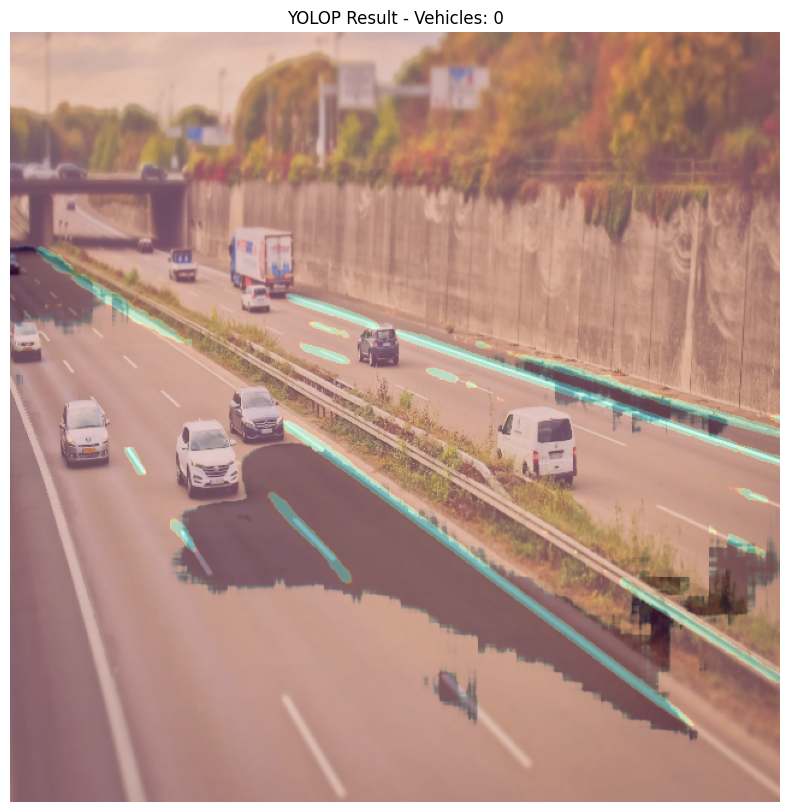

In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# -------------------------------
# 1. Load YOLOP model
# -------------------------------
print("Loading model...")
model = torch.hub.load('hustvl/yolop', 'yolop', pretrained=True)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# -------------------------------
# 2. Load image
# -------------------------------
img_path = "/kaggle/input/datasets/mohan3005/2-lane-images/pexels-photo-221284.webp"

img = cv2.imread(img_path)

if img is None:
    raise Exception("❌ Image not found. Check path!")

print("✅ Image loaded:", img.shape)

img = cv2.resize(img, (640, 640))

# BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -------------------------------
# 3. Convert to tensor
# -------------------------------
img_tensor = img_rgb.transpose(2, 0, 1)
img_tensor = np.expand_dims(img_tensor, 0)
img_tensor = torch.from_numpy(img_tensor).float() / 255.0
img_tensor = img_tensor.to(device)

# -------------------------------
# 4. Run model
# -------------------------------
print("Running model...")
with torch.no_grad():
    pred, da_seg_out, ll_seg_out = model(img_tensor)

# -------------------------------
# 5. Segmentation masks
# -------------------------------
lane_mask = ll_seg_out.squeeze().detach().cpu().numpy()
road_mask = da_seg_out.squeeze().detach().cpu().numpy()

if lane_mask.ndim == 3:
    lane_mask = lane_mask[0]

if road_mask.ndim == 3:
    road_mask = road_mask[0]

lane_mask = (lane_mask * 255).astype(np.uint8)
road_mask = (road_mask * 255).astype(np.uint8)

lane_color = cv2.applyColorMap(lane_mask, cv2.COLORMAP_JET)
road_color = cv2.applyColorMap(road_mask, cv2.COLORMAP_OCEAN)

# overlay
overlay = cv2.addWeighted(img, 0.7, lane_color, 0.3, 0)
overlay = cv2.addWeighted(overlay, 0.7, road_color, 0.3, 0)

# -------------------------------
# 6. Vehicle Detection
# -------------------------------
detections = pred[0][0]

vehicle_classes = [2, 5, 7]  # car, bus, truck
vehicle_count = 0

print("Processing detections...")

if detections is None or len(detections) == 0:
    print("⚠️ No detections found!")

else:
    for det in detections:

        det = det.detach().cpu().numpy()

        if det.ndim > 1:
            det = det[0]

        x1, y1, x2, y2, conf, cls = det[:6]

        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        conf = float(conf)
        cls = int(cls)

        # LOWER threshold for testing
        if conf < 0.1:
            continue

        if cls not in vehicle_classes:
            continue

        vehicle_count += 1

        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)

        cv2.putText(
            overlay,
            f"Vehicle {conf:.2f}",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

# -------------------------------
# 7. Output
# -------------------------------
print("🚗 Vehicles detected:", vehicle_count)

# Save image (IMPORTANT in Kaggle)
output_path = "/kaggle/working/output.jpg"
cv2.imwrite(output_path, overlay)
print(f"✅ Output saved at: {output_path}")

# Show using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOP Result - Vehicles: {vehicle_count}")
plt.axis("off")
plt.show()

Loading model...


Using cache found in /root/.cache/torch/hub/hustvl_yolop_main


✅ Image loaded: (1253, 1880, 3)
Running model...
Processing detections...
🚗 Vehicles detected: 0
✅ Output saved at: /kaggle/working/output.jpg


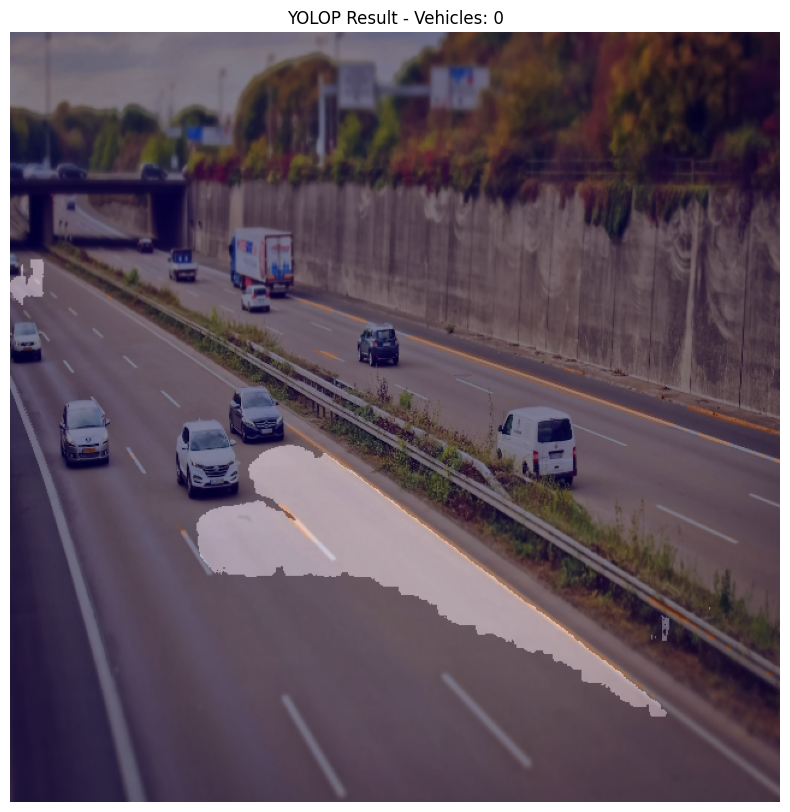

In [7]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# -------------------------------
# 1. Load model
# -------------------------------
print("Loading model...")
model = torch.hub.load('hustvl/yolop', 'yolop', pretrained=True)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# -------------------------------
# 2. Load image
# -------------------------------
img_path = "/kaggle/input/datasets/mohan3005/2-lane-images/pexels-photo-221284.webp"

img = cv2.imread(img_path)
if img is None:
    raise Exception("❌ Image not found!")

print("✅ Image loaded:", img.shape)

# resize
img_resized = cv2.resize(img, (640, 640))

# convert color
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

# -------------------------------
# 3. Convert to tensor
# -------------------------------
img_tensor = img_rgb.transpose(2, 0, 1)
img_tensor = np.expand_dims(img_tensor, 0)
img_tensor = torch.from_numpy(img_tensor).float() / 255.0
img_tensor = img_tensor.to(device)

# -------------------------------
# 4. Run model
# -------------------------------
print("Running model...")
with torch.no_grad():
    pred, da_seg_out, ll_seg_out = model(img_tensor)

# -------------------------------
# 5. Segmentation masks (FIXED)
# -------------------------------
lane_mask = ll_seg_out.squeeze().cpu().numpy()
road_mask = da_seg_out.squeeze().cpu().numpy()

# FIX: convert 3D → 2D
if lane_mask.ndim == 3:
    lane_mask = lane_mask[1]

if road_mask.ndim == 3:
    road_mask = road_mask[1]

# binary masks
lane_mask = (lane_mask > 0.5).astype(np.uint8) * 255
road_mask = (road_mask > 0.5).astype(np.uint8) * 255

# color maps
lane_color = cv2.applyColorMap(lane_mask, cv2.COLORMAP_JET)
road_color = cv2.applyColorMap(road_mask, cv2.COLORMAP_OCEAN)

# overlay
overlay = cv2.addWeighted(img_resized, 0.7, lane_color, 0.3, 0)
overlay = cv2.addWeighted(overlay, 0.7, road_color, 0.3, 0)

# -------------------------------
# 6. Detection (ROBUST FIX)
# -------------------------------
vehicle_count = 0
detections = pred[0]

print("Processing detections...")

if detections is not None:

    for det in detections:

        det = det.detach().cpu().numpy()

        # 🔥 FORCE FLATTEN
        det = det.reshape(-1)

        if det.shape[0] < 6:
            continue

        x1, y1, x2, y2, conf, cls = det[:6]

        # convert safely
        conf = float(conf)
        cls = int(cls)

        # filter weak detections
        if conf < 0.2:
            continue

        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        vehicle_count += 1

        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)

        cv2.putText(
            overlay,
            f"{conf:.2f}",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

else:
    print("⚠️ No detections")

# -------------------------------
# 7. Output
# -------------------------------
print("🚗 Vehicles detected:", vehicle_count)

# save output
output_path = "/kaggle/working/output.jpg"
cv2.imwrite(output_path, overlay)
print(f"✅ Output saved at: {output_path}")

# display (Kaggle)
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title(f"YOLOP Result - Vehicles: {vehicle_count}")
plt.axis("off")
plt.show()

In [10]:
pip install ultralytics scikit-learn opencv-python

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from sklearn.cluster import KMeans

# load YOLO model
model = YOLO("yolov8n.pt")

# load image
img = cv2.imread("/kaggle/input/datasets/mohan3005/2-lane-images/pexels-photo-221284.webp")

# detect vehicles
results = model(img)[0]

centers = []

# classes for vehicles in COCO dataset
vehicle_classes = [2,3,5,7]  
# 2=car,3=motorcycle,5=bus,7=truck

for box in results.boxes:

    cls = int(box.cls[0])

    if cls in vehicle_classes:

        x1,y1,x2,y2 = box.xyxy[0]

        cx = int((x1+x2)/2)
        cy = int((y1+y2)/2)

        centers.append([cx,cy])

        # draw bounding box
        cv2.rectangle(img,(int(x1),int(y1)),
                          (int(x2),int(y2)),
                          (0,255,0),2)

# convert to array
centers = np.array(centers)

# cluster lanes
kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(centers)

# color each lane differently
colors = [(255,0,0),(0,0,255)]

for i,(cx,cy) in enumerate(centers):

    lane_id = labels[i]

    cv2.circle(img,(cx,cy),6,colors[lane_id],-1)

    cv2.putText(
        img,
        f"Lane {lane_id+1}",
        (cx,cy-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        colors[lane_id],
        2
    )

print("Lane 1 vehicles:", list(labels).count(0))
print("Lane 2 vehicles:", list(labels).count(1))

cv2.imshow("Lane detection",img)
cv2.waitKey(0)
cv2.destroyAllWindows()


0: 448x640 8 cars, 2 trucks, 119.3ms
Speed: 3.0ms preprocess, 119.3ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


✅ Image loaded: (1253, 1880, 3)

0: 448x640 8 cars, 2 trucks, 141.0ms
Speed: 5.9ms preprocess, 141.0ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
🚗 Lane 1 vehicles: 9
🚗 Lane 2 vehicles: 1
✅ Output saved at: /kaggle/working/lane_auto.jpg


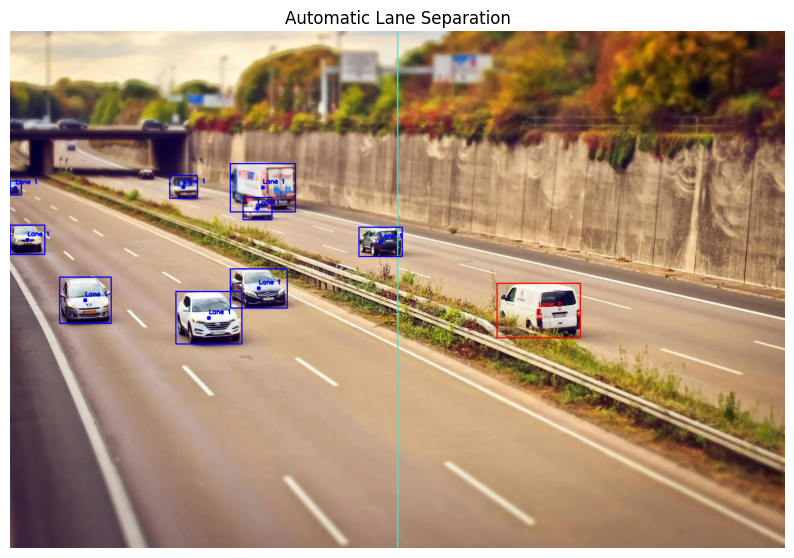

In [1]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load model
# -------------------------------
model = YOLO("yolov8n.pt")

# -------------------------------
# 2. Load image
# -------------------------------
img_path = "/kaggle/input/datasets/mohan3005/2-lane-images/pexels-photo-221284.webp"
img = cv2.imread(img_path)

if img is None:
    raise Exception("❌ Image not found!")

h, w = img.shape[:2]
print("✅ Image loaded:", img.shape)

# -------------------------------
# 3. Detect vehicles
# -------------------------------
results = model(img)[0]

vehicle_classes = [2, 3, 5, 7]  # car, motorcycle, bus, truck

lane1_count = 0
lane2_count = 0

# 🔥 AUTO SPLIT LINE (middle of image)
mid_x = w // 2

# draw split line
cv2.line(img, (mid_x, 0), (mid_x, h), (255, 255, 0), 2)

for box in results.boxes:

    cls = int(box.cls.item())

    if cls in vehicle_classes:

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        # 🔥 AUTO LANE ASSIGNMENT
        if cx < mid_x:
            lane_id = 1
            lane1_count += 1
            color = (255, 0, 0)   # blue
        else:
            lane_id = 2
            lane2_count += 1
            color = (0, 0, 255)   # red

        # draw bounding box
        cv2.rectangle(img,
                      (int(x1), int(y1)),
                      (int(x2), int(y2)),
                      color, 2)

        # draw center
        cv2.circle(img, (cx, cy), 5, color, -1)

        # label
        cv2.putText(
            img,
            f"Lane {lane_id}",
            (cx, cy - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

# -------------------------------
# 4. Output
# -------------------------------
print("🚗 Lane 1 vehicles:", lane1_count)
print("🚗 Lane 2 vehicles:", lane2_count)

# save
output_path = "/kaggle/working/lane_auto.jpg"
cv2.imwrite(output_path, img)
print(f"✅ Output saved at: {output_path}")

# show
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Automatic Lane Separation")
plt.axis("off")
plt.show()

✅ Image loaded: (316, 474, 3)

0: 448x640 18 cars, 1 bus, 101.1ms
Speed: 2.5ms preprocess, 101.1ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)
🚗 Lane 1 vehicles: 7
🚗 Lane 2 vehicles: 12
✅ Output saved at: /kaggle/working/lane_diagonal.jpg


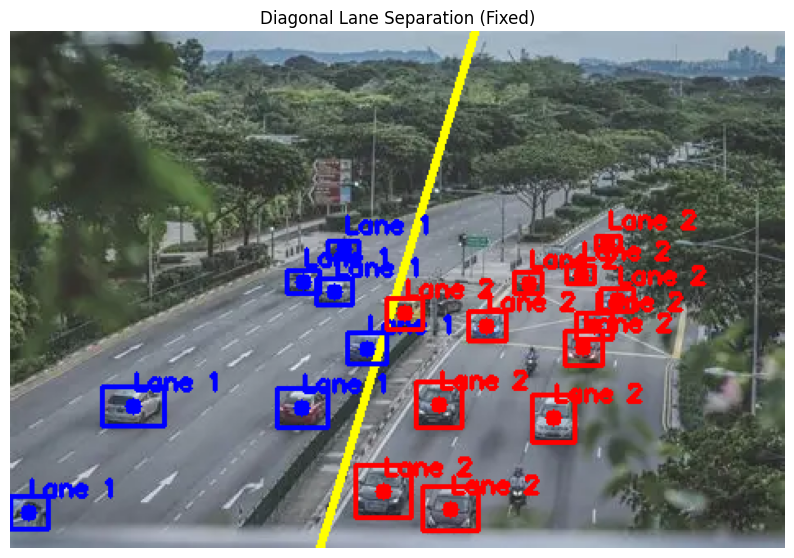

In [11]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load model
# -------------------------------
model = YOLO("yolov8n.pt")

# -------------------------------
# 2. Load image
# -------------------------------
img_path = "/kaggle/input/datasets/mohan3005/test013i12/OIP.webp"
img = cv2.imread(img_path)

if img is None:
    raise Exception("❌ Image not found!")

h, w = img.shape[:2]
print("✅ Image loaded:", img.shape)

# -------------------------------
# 3. Detect vehicles
# -------------------------------
results = model(img)[0]

vehicle_classes = [2, 3, 5, 7]  # car, motorcycle, bus, truck

# -------------------------------
# 4. DEFINE DIAGONAL LANE LINE 🔥
# -------------------------------
# Tune these values if needed
x1_line, y1_line = int(w * 0.4), h
x2_line, y2_line = int(w * 0.6), 0

# draw separator line
cv2.line(img, (x1_line, y1_line), (x2_line, y2_line), (0, 255, 255), 3)

# function to check which side of line
def get_side(cx, cy):
    return (cx - x1_line)*(y2_line - y1_line) - (cy - y1_line)*(x2_line - x1_line)

# -------------------------------
# 5. Assign vehicles to lanes
# -------------------------------
lane1_count = 0
lane2_count = 0

for box in results.boxes:

    cls = int(box.cls.item())

    if cls in vehicle_classes:

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        # 🔥 lane classification
        if get_side(cx, cy) > 0:
            lane_id = 1
            lane1_count += 1
            color = (255, 0, 0)   # Blue
        else:
            lane_id = 2
            lane2_count += 1
            color = (0, 0, 255)   # Red

        # draw box
        cv2.rectangle(img,
                      (int(x1), int(y1)),
                      (int(x2), int(y2)),
                      color, 2)

        # draw center
        cv2.circle(img, (cx, cy), 5, color, -1)

        # label
        cv2.putText(
            img,
            f"Lane {lane_id}",
            (cx, cy - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

# -------------------------------
# 6. Output
# -------------------------------
print("🚗 Lane 1 vehicles:", lane1_count)
print("🚗 Lane 2 vehicles:", lane2_count)

# save output
output_path = "/kaggle/working/lane_diagonal.jpg"
cv2.imwrite(output_path, img)
print(f"✅ Output saved at: {output_path}")

# display (Kaggle)
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Diagonal Lane Separation (Fixed)")
plt.axis("off")
plt.show()

✅ Image loaded: (1253, 1880, 3)

0: 448x640 8 cars, 2 trucks, 115.4ms
Speed: 3.6ms preprocess, 115.4ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)
🚗 Lane 1 vehicles: 5
🚗 Lane 2 vehicles: 5


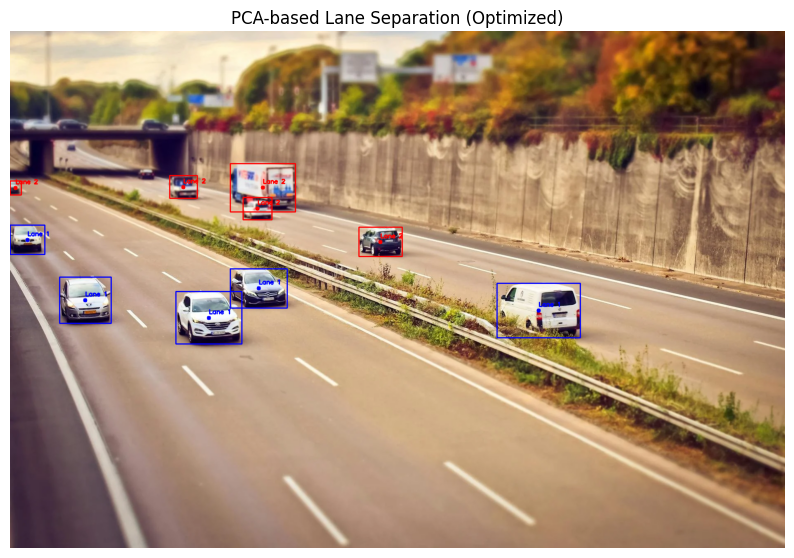

In [10]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# -------------------------------
# 1. Load model
# -------------------------------
model = YOLO("yolov8n.pt")

# -------------------------------
# 2. Load image
# -------------------------------
img_path = "/kaggle/input/datasets/mohan3005/2-lane-images/pexels-photo-221284.webp"
img = cv2.imread(img_path)

if img is None:
    raise Exception("❌ Image not found!")

print("✅ Image loaded:", img.shape)

# -------------------------------
# 3. Detect vehicles
# -------------------------------
results = model(img)[0]

vehicle_classes = [2, 3, 5, 7]

centers = []
boxes_list = []

for box in results.boxes:

    cls = int(box.cls.item())

    if cls in vehicle_classes:

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)

        centers.append([cx, cy])
        boxes_list.append((x1, y1, x2, y2, cx, cy))

# -------------------------------
# 4. Check enough vehicles
# -------------------------------
if len(centers) < 2:
    print("⚠️ Not enough vehicles for lane separation")
else:
    centers_np = np.array(centers)

    # -------------------------------
    # 5. PCA → find road direction
    # -------------------------------
    pca = PCA(n_components=2)
    pca.fit(centers_np)

    direction = pca.components_[0]   # main direction
    normal = pca.components_[1]      # perpendicular

    # -------------------------------
    # 6. Project onto perpendicular axis
    # -------------------------------
    projections = centers_np @ normal

    projections = projections.reshape(-1, 1)

    # -------------------------------
    # 7. Cluster into 2 lanes
    # -------------------------------
    kmeans = KMeans(n_clusters=2, random_state=0)
    labels = kmeans.fit_predict(projections)

    # -------------------------------
    # 8. Draw results
    # -------------------------------
    colors = [(255, 0, 0), (0, 0, 255)]

    lane1_count = list(labels).count(0)
    lane2_count = list(labels).count(1)

    for i, (x1, y1, x2, y2, cx, cy) in enumerate(boxes_list):

        lane_id = labels[i]
        color = colors[lane_id]

        cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)
        cv2.circle(img, (cx, cy), 5, color, -1)

        cv2.putText(img,
                    f"Lane {lane_id+1}",
                    (cx, cy-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    color,
                    2)

    print("🚗 Lane 1 vehicles:", lane1_count)
    print("🚗 Lane 2 vehicles:", lane2_count)

# -------------------------------
# 9. Output
# -------------------------------
output_path = "/kaggle/working/pca_lane.jpg"
cv2.imwrite(output_path, img)

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("PCA-based Lane Separation (Optimized)")
plt.axis("off")
plt.show()